In [16]:
# let import all the modules that we need to inspect the data
#inspection of data is important because before training the model by the dataset we have to check that data is in single form or not all the dimension are same or not is there is any missing values or other so we need to inspect the data and take knowledge about the data so we can train our model according to the data

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [17]:
# here we have to input the dataset from the another folder so we can easily inspect

dataset_path = "../datasets/ecg_data"

# now we care divide the dataset into classes so model easy learn the patterns
classes = [
    "abnormal_heartbeat_ecg_images",
    "myocardial_infarction_ecg_images",
    "normal_ecg_images",
    "post_mi_history_ecg_images"
]

In [18]:
# first we have to count the number of dataset images we have to clear in our mind set that how many we have to use in training and how many in testing

image_counts = {}

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    count = len([
        f for f in os.listdir(class_path)                       # Here we use os modules function to count how many images are there in the directory
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ])

    image_counts[class_name] = count

# Now convert the dict. into dataframe for easy access
df = pd.DataFrame(
    image_counts.items(),
    columns=["Class", "Images"]
)

df

,Class,Images
0,abnormal_heartbeat_ecg_images,233
1,myocardial_infarction_ecg_images,239
2,normal_ecg_images,284
3,post_mi_history_ecg_images,172


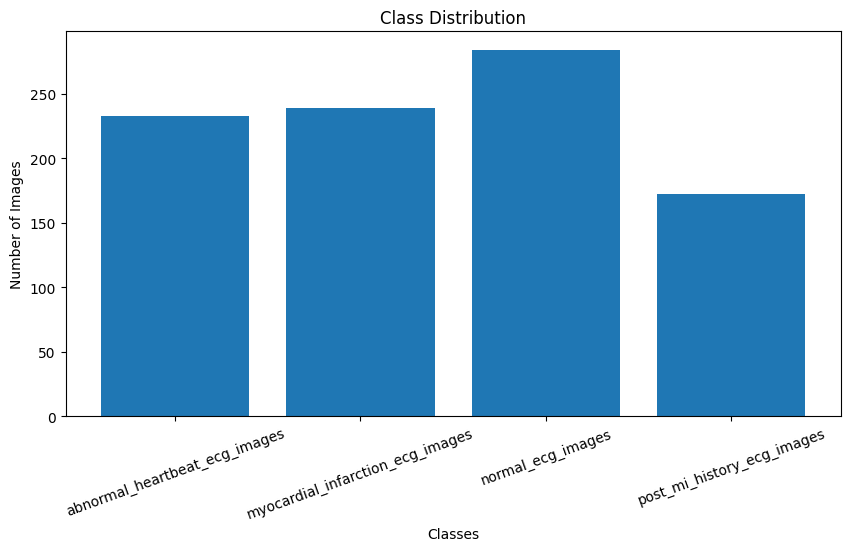

In [19]:
# now we plot a graph so see the number of images for better inspection

plt.figure(figsize=(10,5))

plt.bar(
    image_counts.keys(),
    image_counts.values()
)

plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.xticks(rotation=20)

plt.show()

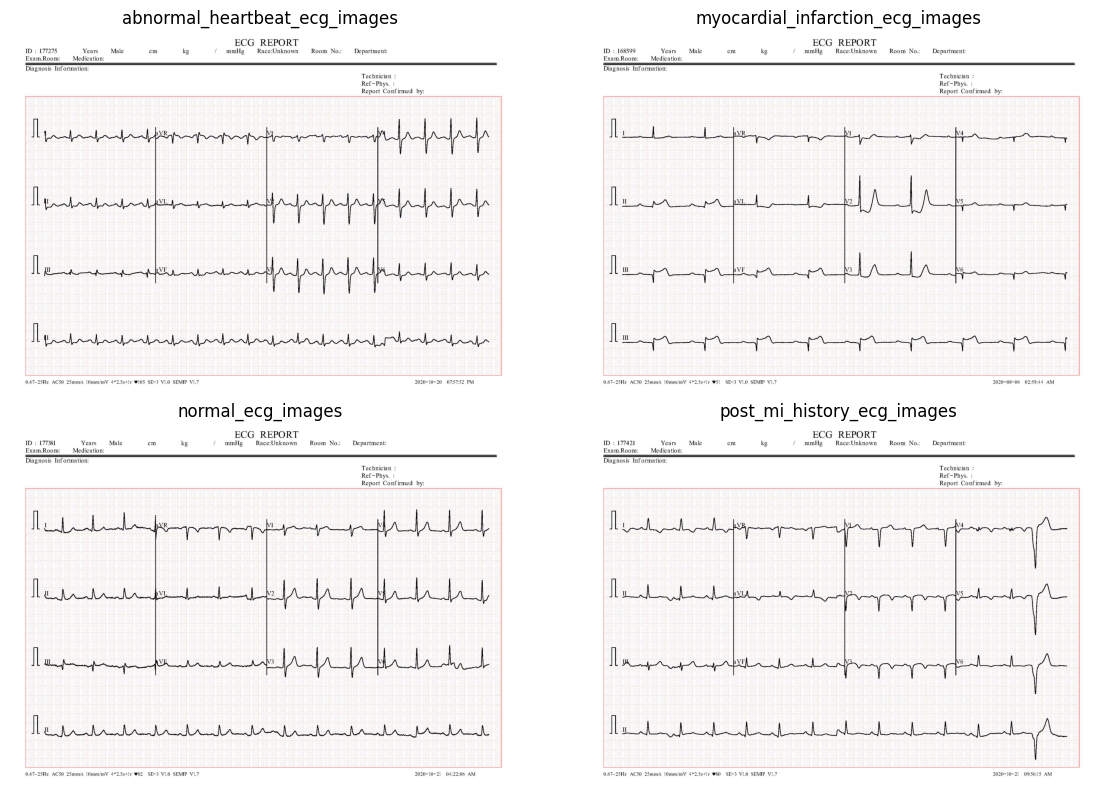

In [20]:
# here we display one-one image from dataset to look how the images look

plt.figure(figsize=(12,8))

for i, class_name in enumerate(classes):

    class_path = os.path.join(dataset_path, class_name)

    image_file = os.listdir(class_path)[0]

    image_path = os.path.join(class_path, image_file)

    image = Image.open(image_path)

    plt.subplot(2,2,i+1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
# here we have to know about the size of the images

sizes = []

for class_name in classes:

    class_path = os.path.join(dataset_path, class_name)

    for image_file in os.listdir(class_path):

        image_path = os.path.join(class_path, image_file)

        image = Image.open(image_path)

        sizes.append(image.size)

unique_sizes = set(sizes)

print("Number of unique image sizes:", len(unique_sizes))

print(unique_sizes)

Number of unique image sizes: 1
{(2213, 1572)}


In [22]:
# let check the format of all the images that present in the dataset for validate the no issue become later

formats = set()

for class_name in classes:

    class_path = os.path.join(dataset_path, class_name)

    for image_file in os.listdir(class_path):

        image_path = os.path.join(class_path, image_file)

        image = Image.open(image_path)

        formats.add(image.format)

print(formats)

{'JPEG'}


In [23]:
# here we label the data that how model predict the data

label_map = {
    0: "Normal ECG",
    1: "Abnormal Heartbeat",
    2: "Myocardial Infarction",
    3: "Post MI History"
}

print(label_map)

{0: 'Normal ECG', 1: 'Abnormal Heartbeat', 2: 'Myocardial Infarction', 3: 'Post MI History'}
